In [14]:
#pip install timm

## Importamos librerias y cargamos los datos

In [ ]:
import random
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import WeightedRandomSampler, DataLoader, Subset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import timm

SEED = 1
IMG_SIZE = 224 
BACHT_SIZE = 64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

PROJECT_ROOT = Path.cwd().parent

DATASET_DIR = PROJECT_ROOT / "DATASET" / "Insectos" 

MODEL_DIR = PROJECT_ROOT / "NASNetMobile" / "modelos"
RESULTS_DIR = PROJECT_ROOT / "NASNetMobile" / "resultados"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

base_dataset = datasets.ImageFolder(DATASET_DIR)

classes = base_dataset.classes
num_classes = len(classes)

print("Cantidad de datos =", len(base_dataset), "Cantidad de clases =", num_classes)

print("\nClases encontradas:")
for i, clase in enumerate(classes):
    print(f"{i:2d} -> {clase}")

Dispositivo: cuda
Cantidad de datos = 20325 Cantidad de clases = 23

Clases encontradas:
 0 -> Abeja
 1 -> Abeja Malifera (Apis)
 2 -> Abejorro (Bombus)
 3 -> Avispa
 4 -> Chinche
 5 -> Chinche rayada
 6 -> Escarabajo
 7 -> Escarabajo floricola (Oedem)
 8 -> Hormiga
 9 -> Lepidóptero (Mariposa-Polilla)
10 -> Mariquita
11 -> Mosca
12 -> Mosca cernidora (Episyrphus)
13 -> Mosca cernidora (Eristalis)
14 -> Mosca cernidora (Eupeodes)
15 -> Mosca cernidora (Myathropa)
16 -> Mosca cernidora (Sphaerophoria)
17 -> Mosca cernidora (Syrphus)
18 -> Mosca danzante (Empididae)
19 -> Mosca de la carne (Sarcophagidae)
20 -> Mosca escorpión
21 -> Mosca pequeña
22 -> other


In [16]:
targets = base_dataset.targets
indices = list(range(len(targets)))

train_idx, temp_idx, train_targets, temp_targets = train_test_split(
    indices, targets, test_size=0.2, stratify=targets, random_state=SEED
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=temp_targets, random_state=SEED
)

## preparamos los datos

In [17]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.RandomVerticalFlip(p=0.5),   
    transforms.RandomRotation(45),          
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [18]:
class DatasetTransformWrapper(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self): return len(self.subset)

train_dataset = DatasetTransformWrapper(Subset(base_dataset, train_idx), transform=train_transforms)
val_dataset = DatasetTransformWrapper(Subset(base_dataset, val_idx), transform=test_transforms)
test_dataset = DatasetTransformWrapper(Subset(base_dataset, test_idx), transform=test_transforms)

class_weights = {clase: 1.0 / count for clase, count in Counter(train_targets).items()}
pesos_muestras = torch.tensor([class_weights[target] for target in train_targets], dtype=torch.float)

sampler = WeightedRandomSampler(weights=pesos_muestras, num_samples=len(pesos_muestras), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BACHT_SIZE, sampler=sampler, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BACHT_SIZE, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BACHT_SIZE, shuffle=False, pin_memory=True)

## Funciones de train t val

In [ ]:
from tqdm import tqdm

def fit(model, train_dataloader, val_dataloader, epochs=20):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.CrossEntropyLoss()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(1, epochs+1):
        model.train()
        train_loss, train_acc = [], []
        bar = tqdm(train_dataloader, desc=f"Epoch {epoch}/{epochs} [Train]")
        for X, y in bar:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
            acc = (y == torch.argmax(y_hat, axis=1)).sum().item() / len(y)
            train_acc.append(acc)
            bar.set_postfix(loss=f"{np.mean(train_loss):.5f}", acc=f"{np.mean(train_acc):.5f}")
            
        model.eval()
        val_loss, val_acc = [], []
        bar = tqdm(val_dataloader, desc=f"Epoch {epoch}/{epochs} [Val  ]")
        with torch.no_grad():
            for X, y in bar:
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)
                val_loss.append(loss.item())
                acc = (y == torch.argmax(y_hat, axis=1)).sum().item() / len(y)
                val_acc.append(acc)
                bar.set_postfix(val_loss=f"{np.mean(val_loss):.5f}", val_acc=f"{np.mean(val_acc):.5f}")
        
        history['train_loss'].append(np.mean(train_loss))
        history['train_acc'].append(np.mean(train_acc))
        history['val_loss'].append(np.mean(val_loss))
        history['val_acc'].append(np.mean(val_acc))
        print(f"Resultado -> loss: {np.mean(train_loss):.5f} | val_loss: {np.mean(val_loss):.5f} | acc: {np.mean(train_acc):.5f} | val_acc: {np.mean(val_acc):.5f}\n")
    return history

def plot_learning_curves(history):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(epochs, history['train_loss'], label='Train Loss', marker='o', color='blue')
    ax1.plot(epochs, history['val_loss'], label='Validation Loss', marker='o', color='red')
    ax1.set_title('Evolución de la Pérdida (Loss)')
    ax1.set_xlabel('Épocas'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.7)
    
    ax2.plot(epochs, history['train_acc'], label='Train Accuracy', marker='o', color='blue')
    ax2.plot(epochs, history['val_acc'], label='Validation Accuracy', marker='o', color='red')
    ax2.set_title('Evolución de la Precisión (Accuracy)')
    ax2.set_xlabel('Épocas'); ax2.set_ylabel('Accuracy'); ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout(); plt.show()

def evaluate_model(model, dataloader, class_names):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(14, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Matriz de Confusión - Transfer Learning', fontsize=16)
    plt.ylabel('Valor Real'); plt.xlabel('Predicción')
    plt.xticks(rotation=90); plt.yticks(rotation=0); plt.tight_layout(); plt.show()


## Transfer Learning

Epoch 1/20 [Val  ]: 100%|██████████| 32/32 [00:07<00:00,  4.23it/s, val_acc=0.46370, val_loss=1.87361]


Resultado -> loss: 1.69305 | val_loss: 1.87361 | acc: 0.58033 | val_acc: 0.46370



Epoch 2/20 [Val  ]: 100%|██████████| 32/32 [00:06<00:00,  5.00it/s, val_acc=0.56413, val_loss=1.52851]


Resultado -> loss: 1.04005 | val_loss: 1.52851 | acc: 0.71612 | val_acc: 0.56413



Epoch 3/20 [Val  ]: 100%|██████████| 32/32 [00:06<00:00,  5.25it/s, val_acc=0.61100, val_loss=1.31103]


...

Resultado -> loss: 0.57627 | val_loss: 0.90091 | acc: 0.81795 | val_acc: 0.72152



Epoch 19/20 [Val  ]: 100%|██████████| 32/32 [00:08<00:00,  3.97it/s, val_acc=0.66455, val_loss=1.04630]


Resultado -> loss: 0.58268 | val_loss: 1.04630 | acc: 0.81354 | val_acc: 0.66455



Epoch 20/20 [Val  ]: 100%|██████████| 32/32 [00:07<00:00,  4.17it/s, val_acc=0.66602, val_loss=1.06102]


Resultado -> loss: 0.58288 | val_loss: 1.06102 | acc: 0.81232 | val_acc: 0.66602



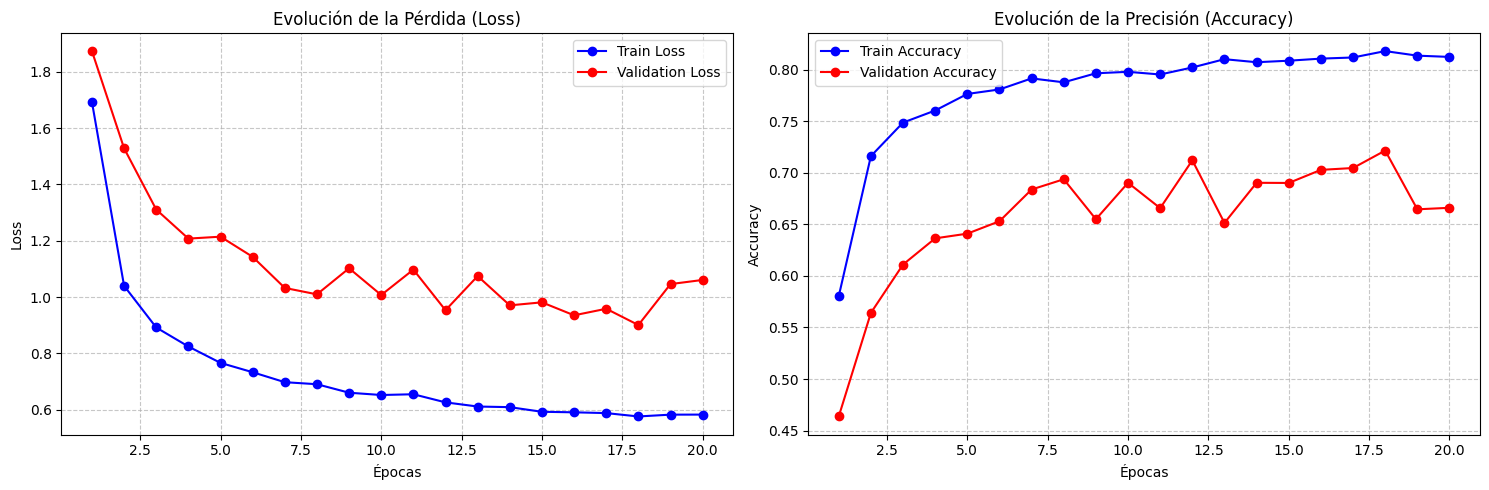

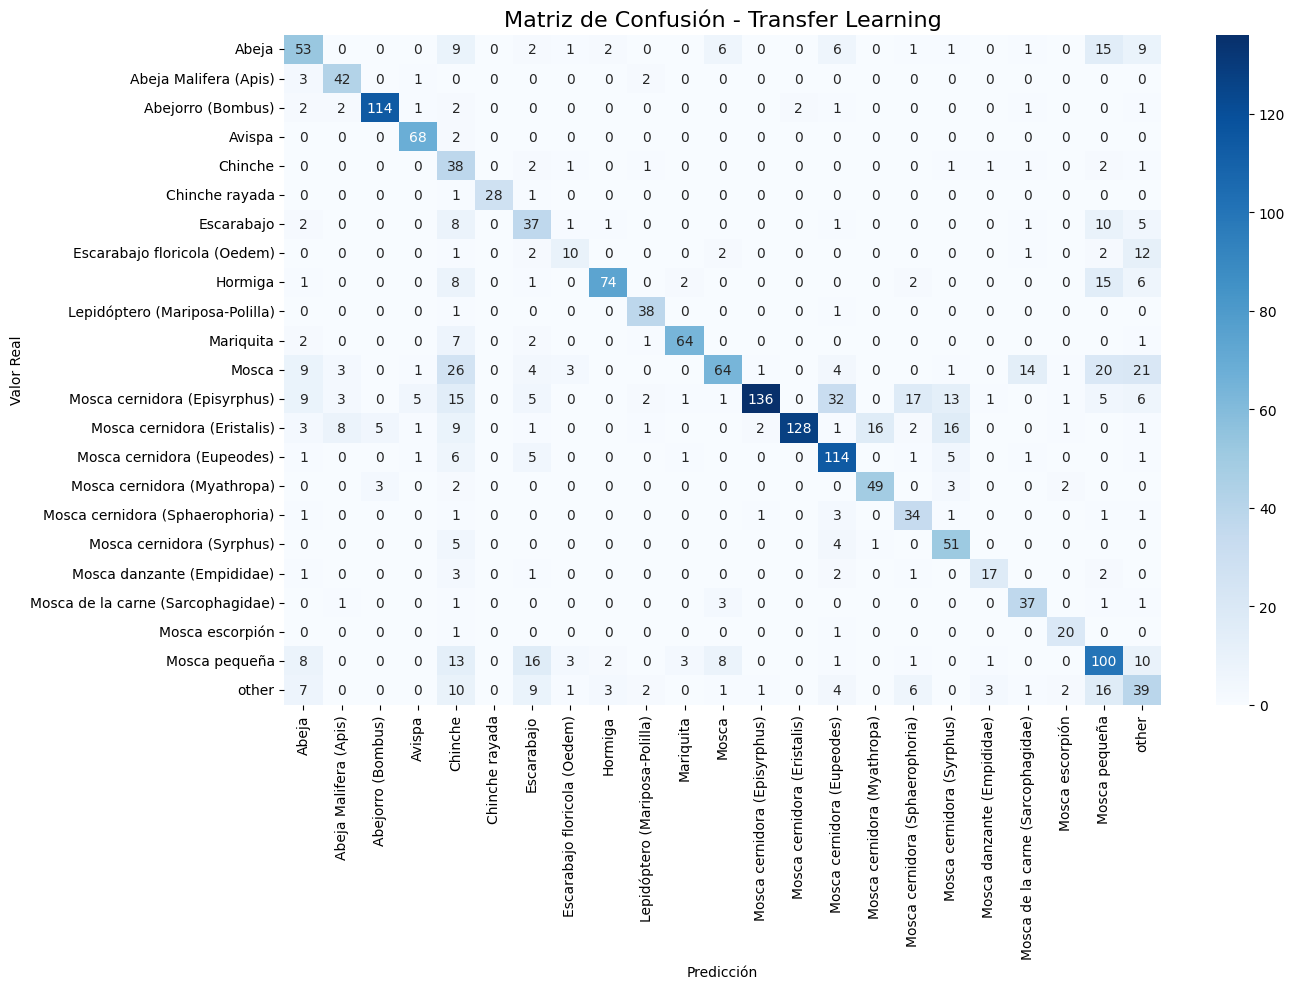

Modelo guardado en: c:\Users\ASUS TUF GAMING A15\Desktop\erick\cico\2026\2-26\SIS421\Labs\Lab1\NASNetMobile\modelos\nasnet_mobile_tl.pth


In [ ]:
modelo_nasnet = timm.create_model('NASNetMobile', pretrained=True)

# Congelamos los pesos base
for param in modelo_nasnet.parameters():
    param.requires_grad = False

# Cambiamos y descongelamos la capa final para nuestros insectos
modelo_nasnet.reset_classifier(num_classes)
modelo_nasnet = modelo_nasnet.to(device)

historial_nasnet = fit(modelo_nasnet, train_loader, val_loader, epochs=20)

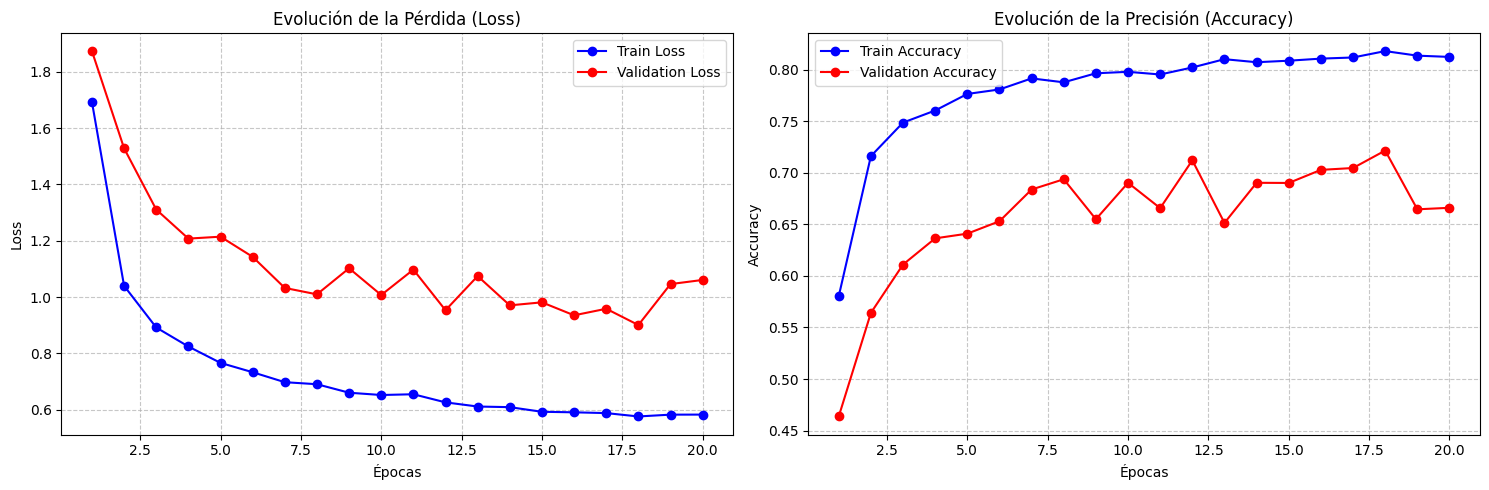

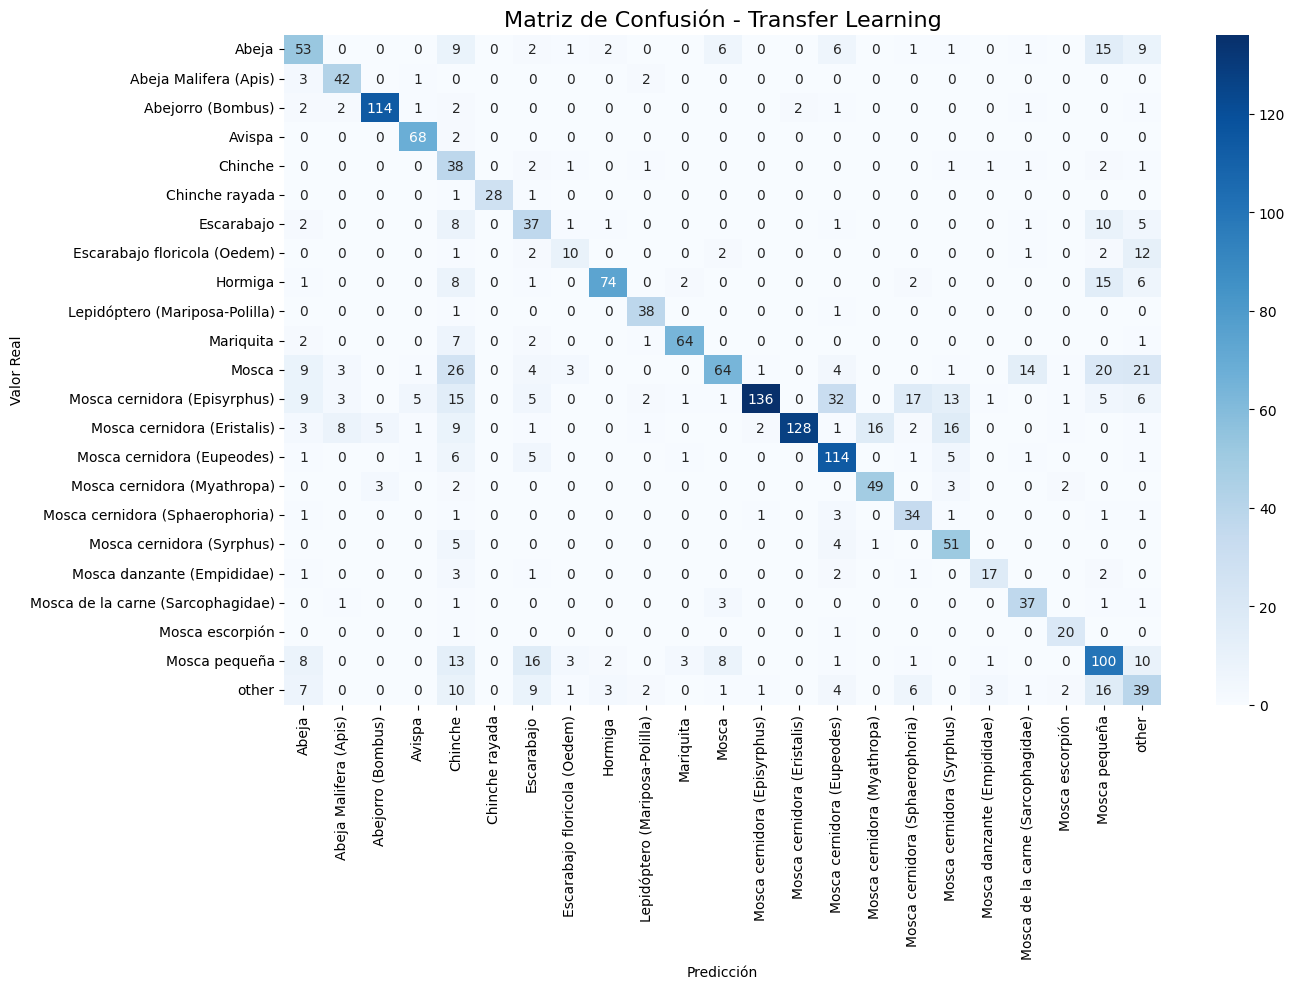

Modelo guardado en: c:\Users\ASUS TUF GAMING A15\Desktop\erick\cico\2026\2-26\SIS421\Labs\Lab1\NASNetMobile\modelos\nasnet_mobile_tl.pth


In [21]:
plot_learning_curves(historial_nasnet)
evaluate_model(modelo_nasnet, val_loader, classes)

# Guardarmos resultados
ruta_modelo = MODEL_DIR / "nasnet_mobile_tl.pth"
ruta_historial = RESULTS_DIR / "historial_nasnet_mobile.pt"
torch.save(modelo_nasnet.state_dict(), ruta_modelo)
torch.save(historial_nasnet, ruta_historial)
print(f"Modelo guardado en: {ruta_modelo}")